In [1]:
# Cell 1
import kagglehub
from kagglehub import KaggleDatasetAdapter

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "naserabdullahalam/phishing-email-dataset",
    "phishing_email.csv",
)
df.head()

/tmp/ipykernel_719/1726488066.py:5: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'phishing-email-dataset' dataset.


,text_combined,label
0,hpl nom may 25 2001 see attached file hplno 52...,0
1,nom actual vols 24 th forwarded sabrae zajac h...,0
2,enron actuals march 30 april 1 201 estimated a...,0
3,hpl nom may 30 2001 see attached file hplno 53...,0
4,hpl nom june 1 2001 see attached file hplno 60...,0


In [2]:
# Cell 3 — basic shape and column check
print("Shape (rows, columns):", df.shape)
print("\nColumn names:", df.columns.tolist())
df.info()

Shape (rows, columns): (82486, 2)

Column names: ['text_combined', 'label']
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 82486 entries, 0 to 82485
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   text_combined  82486 non-null  object
 1   label          82486 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 1.3+ MB


In [3]:
# Cell 4 — missing values and duplicates
print("Missing values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

Missing values per column:
 text_combined    0
label            0
dtype: int64

Duplicate rows: 408


In [4]:
# Cell 5 — class balance (this dataset is usually labeled 0 = legitimate, 1 = phishing)
df['label'].value_counts()

,count
label,
1,42891
0,39595


In [5]:
# Cell 6 — peek at one example of each class
print("Example phishing email:\n", df[df['label'] == 1].iloc[0])
print("\nExample legitimate email:\n", df[df['label'] == 0].iloc[0])

Example phishing email:
 text_combined    link dwl g 510 802 11 g wireless pci lan adapt...
label                                                            1
Name: 3503, dtype: object

Example legitimate email:
 text_combined    hpl nom may 25 2001 see attached file hplno 52...
label                                                            0
Name: 0, dtype: object


In [6]:
# Cell 7 — remove duplicate emails
df = df.drop_duplicates()
print("New shape after removing duplicates:", df.shape)

New shape after removing duplicates: (82078, 2)


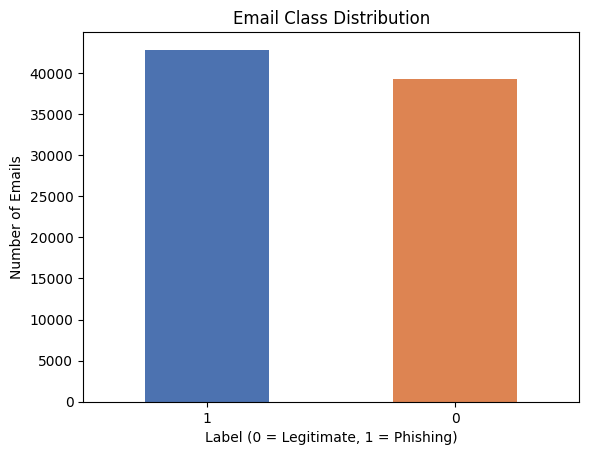

In [7]:
# Cell 8 — visualize class distribution
import matplotlib.pyplot as plt

df['label'].value_counts().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title('Email Class Distribution')
plt.xlabel('Label (0 = Legitimate, 1 = Phishing)')
plt.ylabel('Number of Emails')
plt.xticks(rotation=0)
plt.show()

In [8]:
# Cell 9 — engineer extra features from the raw text
import re

df['text_length'] = df['text_combined'].apply(len)
df['url_count'] = df['text_combined'].apply(lambda t: len(re.findall(r'http\S+|www\.\S+', str(t))))
df['digit_count'] = df['text_combined'].apply(lambda t: sum(c.isdigit() for c in str(t)))

df[['text_length', 'url_count', 'digit_count', 'label']].groupby('label').mean()

,text_length,url_count,digit_count
label,,,
0,1541.456147,1.738358,82.858028
1,1060.692520,2.077092,68.389917


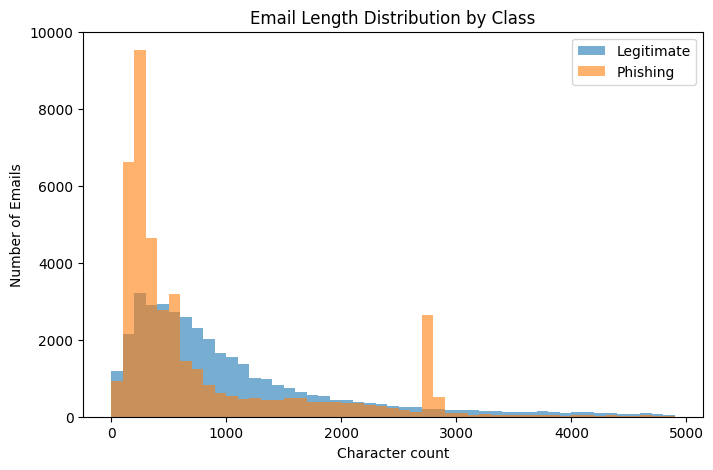

In [9]:
# Cell 10 — visualize email length by class
plt.figure(figsize=(8, 5))
bins = range(0, 5000, 100)
df[(df['label'] == 0) & (df['text_length'] < 5000)]['text_length'].plot(kind='hist', bins=bins, alpha=0.6, label='Legitimate')
df[(df['label'] == 1) & (df['text_length'] < 5000)]['text_length'].plot(kind='hist', bins=bins, alpha=0.6, label='Phishing')
plt.title('Email Length Distribution by Class')
plt.xlabel('Character count')
plt.ylabel('Number of Emails')
plt.legend()
plt.show()

In [10]:
# Cell 11 — clean and normalize the email text
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'<.*?>', ' ', text)              # strip HTML tags
    text = re.sub(r'http\S+|www\.\S+', ' ', text)    # strip URLs
    text = re.sub(r'[^a-z\s]', ' ', text)            # keep only letters
    text = re.sub(r'\s+', ' ', text).strip()         # collapse extra spaces
    return text

df['clean_text'] = df['text_combined'].apply(clean_text)
df[['text_combined', 'clean_text']].head()

,text_combined,clean_text
0,hpl nom may 25 2001 see attached file hplno 52...,hpl nom may see attached file hplno xls hplno xls
1,nom actual vols 24 th forwarded sabrae zajac h...,nom actual vols th forwarded sabrae zajac hou ...
2,enron actuals march 30 april 1 201 estimated a...,enron actuals march april estimated actuals ma...
3,hpl nom may 30 2001 see attached file hplno 53...,hpl nom may see attached file hplno xls hplno xls
4,hpl nom june 1 2001 see attached file hplno 60...,hpl nom june see attached file hplno xls hplno...


In [11]:
# New cell — catch and remove duplicates that only appear after cleaning
post_clean_dupes = df['clean_text'].duplicated().sum()
print("Duplicate rows after cleaning:", post_clean_dupes)

df = df.drop_duplicates(subset='clean_text').reset_index(drop=True)
print("Shape after removing post-cleaning duplicates:", df.shape)

Duplicate rows after cleaning: 1352
Shape after removing post-cleaning duplicates: (80726, 6)


In [12]:
# Cell 12 — TF-IDF vectorization
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer(max_features=5000, min_df=5, max_df=0.9)
X_tfidf = tfidf.fit_transform(df['clean_text'])
print("TF-IDF matrix shape:", X_tfidf.shape)

TF-IDF matrix shape: (80726, 5000)


In [13]:
# Cell 13 — combine TF-IDF with the handcrafted features

from scipy.sparse import hstack, csr_matrix

extra_features = csr_matrix(df[['text_length', 'url_count', 'digit_count']].values)
X = hstack([X_tfidf, extra_features])
y = df['label']
print("Final feature matrix shape:", X.shape)

Final feature matrix shape: (80726, 5003)


In [14]:
# Cell 14 — train/test split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)

Training set size: (64580, 5003)
Testing set size: (16146, 5003)


In [15]:
# Cell 15 — initialize and train the Random Forest
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Model trained on", X_train.shape[0], "emails.")

Model trained on 64580 emails.


In [16]:
# Cell 16 — quick sanity check (just to confirm it learned something — not the real evaluation)
print("Quick accuracy check:", rf_model.score(X_test, y_test))

Quick accuracy check: 0.9848259630868327


In [17]:
# Cell 17 — check for duplicates that only appear after cleaning
print("Duplicate rows after cleaning:", df['clean_text'].duplicated().sum())

Duplicate rows after cleaning: 0


In [18]:
# Cell 18 — full evaluation: precision, recall, F1, ROC-AUC
from sklearn.metrics import classification_report, accuracy_score, roc_auc_score

y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

print("Accuracy:", accuracy_score(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))
print()
print(classification_report(y_test, y_pred,
      target_names=['Legitimate (0)', 'Phishing (1)'], digits=4))

Accuracy: 0.9848259630868327
ROC-AUC: 0.9983335331747905

                precision    recall  f1-score   support

Legitimate (0)     0.9828    0.9850    0.9839      7602
  Phishing (1)     0.9866    0.9847    0.9856      8544

      accuracy                         0.9848     16146
     macro avg     0.9847    0.9848    0.9848     16146
  weighted avg     0.9848    0.9848    0.9848     16146



[[7488  114]
 [ 131 8413]]


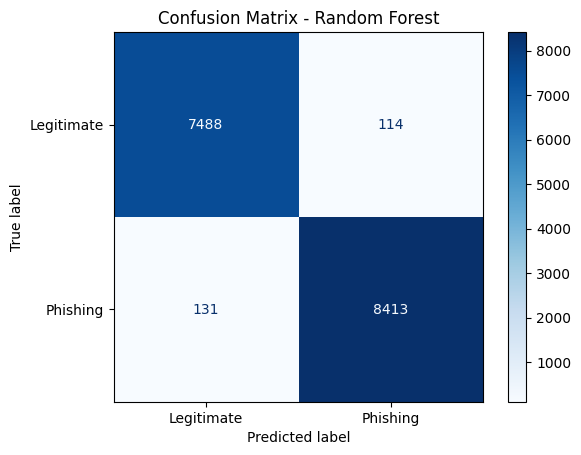

In [19]:
# Cell 19 — confusion matrix
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
print(cm)   # layout: [[TN, FP], [FN, TP]]

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legitimate', 'Phishing'])
disp.plot(cmap='Blues', values_format='d')
plt.title('Confusion Matrix - Random Forest')
plt.show()

 1. wrote                0.0274
 2. aug                  0.0266
 3. enron                0.0229
 4. digit_count          0.0215
 5. thanks               0.0171
 6. text_length          0.0152
 7. url_count            0.0141
 8. pm                   0.0141
 9. list                 0.0119
10. would                0.0088
11. university           0.0083
12. cc                   0.0081
13. group                0.0081
14. mailing              0.0080
15. im                   0.0076
16. money                0.0071
17. vince                0.0069
18. opensuse             0.0068
19. attached             0.0063
20. subject              0.0062

Share of importance from the 3 handcrafted features: 0.05086467539621754


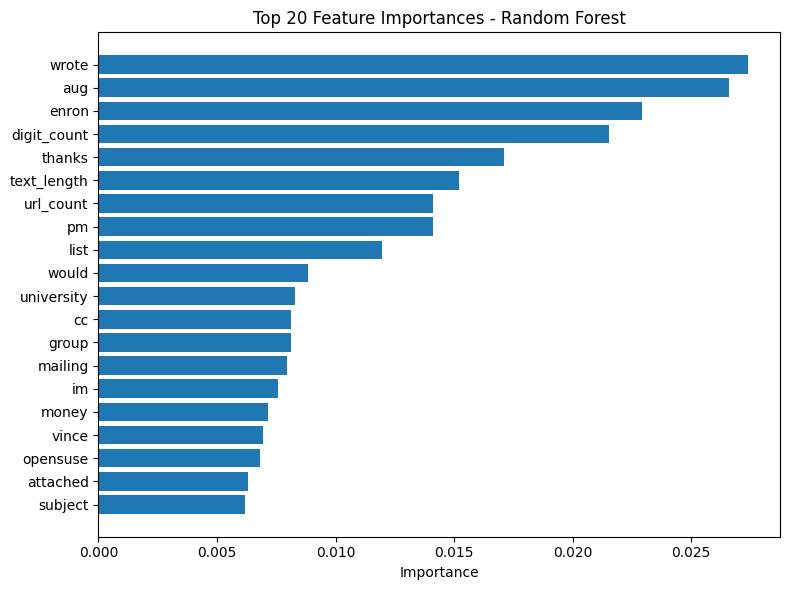

In [20]:
# Cell 20 — top 20 most important features
import numpy as np

feature_names = list(tfidf.get_feature_names_out()) + ['text_length', 'url_count', 'digit_count']
importances = rf_model.feature_importances_
top_idx = np.argsort(importances)[::-1][:20]

for rank, i in enumerate(top_idx, start=1):
    print(f"{rank:2d}. {feature_names[i]:<20} {importances[i]:.4f}")

print("\nShare of importance from the 3 handcrafted features:", importances[-3:].sum())

plt.figure(figsize=(8, 6))
plt.barh([feature_names[i] for i in top_idx][::-1], importances[top_idx][::-1])
plt.title('Top 20 Feature Importances - Random Forest')
plt.xlabel('Importance')
plt.tight_layout()
plt.show()

In [21]:
import joblib, os, sklearn
joblib.dump(tfidf, "tfidf.joblib", compress=3)
joblib.dump(rf_model, "rf_model.joblib", compress=3)
print("scikit-learn version:", sklearn.__version__)
for f in ["tfidf.joblib", "rf_model.joblib"]:
    print(f, round(os.path.getsize(f)/1e6, 1), "MB")

scikit-learn version: 1.6.1
tfidf.joblib 0.1 MB
rf_model.joblib 15.1 MB
